In [14]:
# Cargar librerias
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [15]:
# Cargar la imagen
img_path = "10_ieee.png"
bgr_img = cv2.imread(img_path)

# Convertir a escala de grises
gray_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)

In [16]:
# Normalizar la imagen a una escala de 0 a 1
gray_img = gray_img.astype("float32")/255

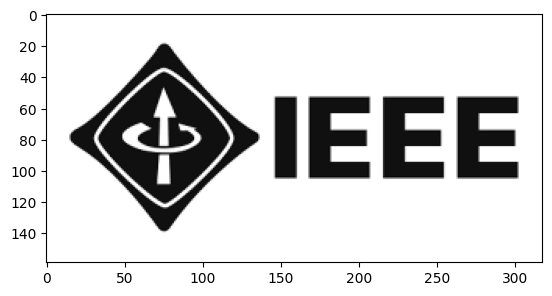

In [17]:
# plot imagen
plt.imshow(gray_img, cmap='gray')
plt.show()

In [18]:
gray_img

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], dtype=float32)

In [19]:
# Sedefine un filtro inicial
filter_vals = np.array([[-1, -1, 1, 1], [-1, -1, 1, 1], [-1, -1, 1, 1], [-1, -1, 1, 1]])
print('Tamaño del filtro: ', filter_vals.shape)

Tamaño del filtro:  (4, 4)


In [20]:
# Definir 4 filtros, en base a la rotación de filter_vals
filter_1 = filter_vals
filter_2 = -filter_1
filter_3 = filter_1.T
filter_4 = -filter_3
filters = np.array([filter_1, filter_2, filter_3, filter_4])

print('Filter 1: \n', filter_1)

Filter 1: 
 [[-1 -1  1  1]
 [-1 -1  1  1]
 [-1 -1  1  1]
 [-1 -1  1  1]]


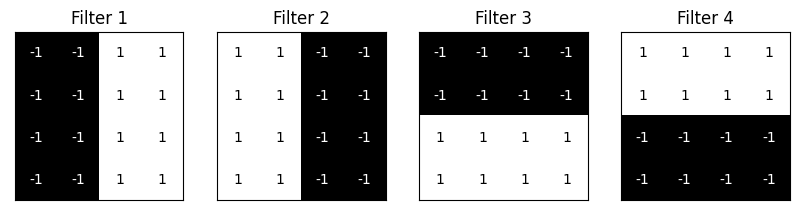

In [21]:
# MOstrar los 4 filtros

fig = plt.figure(figsize=(10, 5))
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1, xticks=[], yticks=[])
    ax.imshow(filters[i], cmap='gray')
    ax.set_title('Filter %s' % str(i+1))
    width, height = filters[i].shape
    for x in range(width):
        for y in range(height):
            ax.annotate(str(filters[i][x][y]), xy=(y,x),
                        horizontalalignment='center',
                        verticalalignment='center',
                        color='white' if filters[i][x][y]<0 else 'black')

In [22]:
# Implementar una red convolucional

import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    
    def __init__(self, weight):
        super(Net, self).__init__()
        # Inicializamos los pesos de la capa convolucional con los pesos de los 4 filtros definidos
        k_height, k_width = weight.shape[2:]
        # Asumimos que hay 4 filtros en escala de grises    
        self.conv = nn.Conv2d(1, 4, kernel_size=(k_height, k_width), bias=False)
        self.conv.weight = torch.nn.Parameter(weight)

    def forward(self, x):
        # Se calucula la convolucion
        # Se obtiene la pre-activacion y la post-activacion
        conv_x = self.conv(x)
        activated_x = F.relu(conv_x)
        
        # Se retorna ambas capas        
        return conv_x, activated_x

# Cargar los pesos 
weight = torch.from_numpy(filters).unsqueeze(1).type(torch.FloatTensor)

# Cargo el modelo
model = Net(weight)
print(model)

Net(
  (conv): Conv2d(1, 4, kernel_size=(4, 4), stride=(1, 1), bias=False)
)


In [23]:
# Para visualizar
def viz_layer(layer, n_filters= 4):
    fig = plt.figure(figsize=(20, 20))
    
    for i in range(n_filters):
        ax = fig.add_subplot(1, n_filters, i+1, xticks=[], yticks=[])
        # capa de salida        
        ax.imshow(np.squeeze(layer[0,i].data.numpy()), cmap='gray')
        ax.set_title('Output %s' % str(i+1))

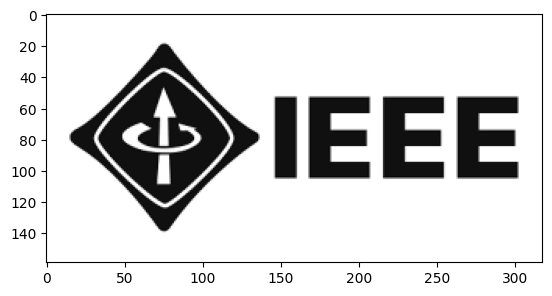

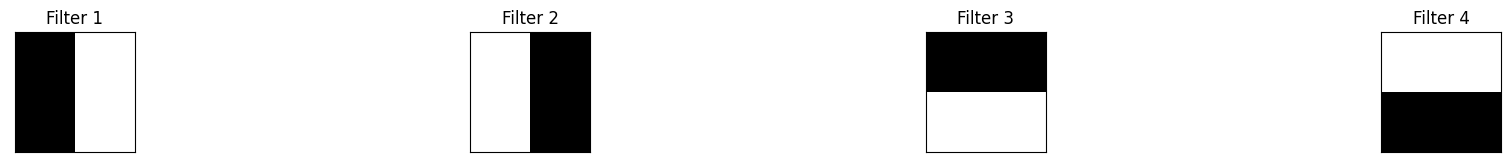

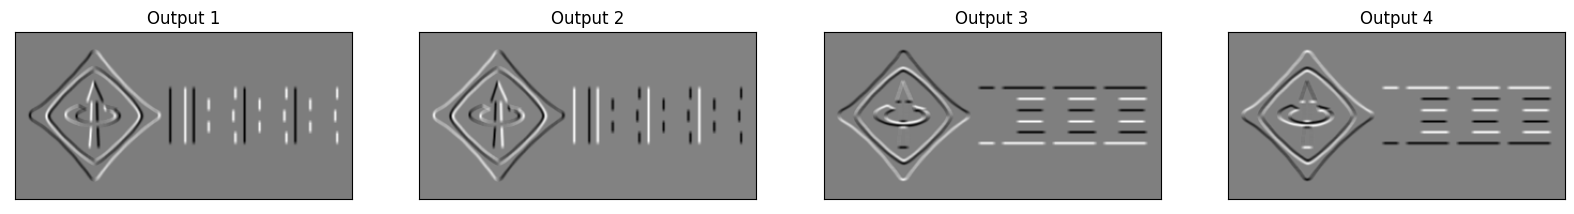

In [24]:
# Visualizar la imagen original
plt.imshow(gray_img, cmap='gray')

# Se vizualiza los filtros aplicados a la imagen
fig = plt.figure(figsize=(12, 6))
fig.subplots_adjust(left=0, right=1.5, bottom=0.8, top=1, hspace=0.05, wspace=0.05)
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1, xticks=[], yticks=[])
    ax.imshow(filters[i], cmap='gray')
    ax.set_title('Filter %s' % str(i+1))

    
# Se convierte la imagen a un tensor
gray_img_tensor = torch.from_numpy(gray_img).unsqueeze(0).unsqueeze(1)

# Se obtiene la capa convolucional y la capa activada
conv_layer, activated_layer = model(gray_img_tensor)

# Se visualiza la salida de la capa convolucional
viz_layer(conv_layer)

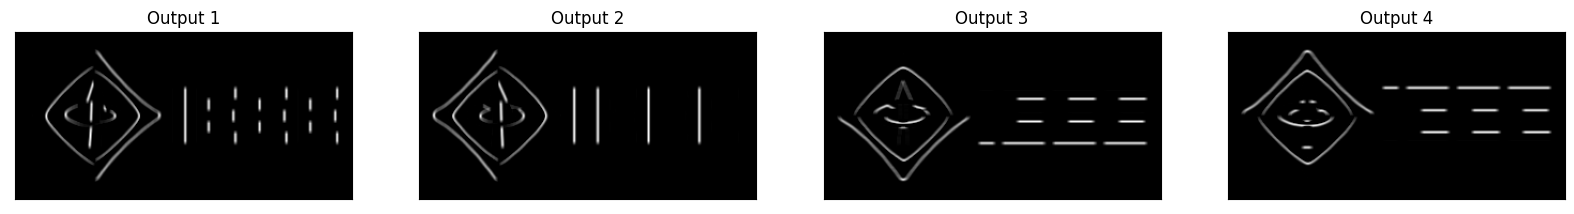

In [25]:
# Aplicar la funcion de activacion
viz_layer(activated_layer)

In [28]:
# Imprimo la imagen inicial, la imagen luego del filtro1 y liego de la activacion, todos como arrays
print('Imagen original')
print(gray_img_tensor)

print('Imagen luego del filtro 1')
print(conv_layer[0,0])

print('Imagen luego de la activacion')
print(activated_layer[0,0])


Imagen original
tensor([[[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]]])
Imagen luego del filtro 1
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], grad_fn=<SelectBackward0>)
Imagen luego de la activacion
tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], grad_fn=<SelectBackward0>)
